# Post-Workout Recovery & Stress Analysis
Deep dive analysis on how post-workout factors affect stress levels and recovery patterns.

**Objective:** Identify single and multiple features that correlate with stress levels during recovery.
**Approach:** Correlation matrix analysis on relevant recovery-related features only.

## 1. Setup & Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Load the CSV data
df = pd.read_csv('../reports/health_snapshots/health_snapshots_2026-04-11_to_2026-07-18.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nColumns available: {len(df.columns)}")

Data shape: (99, 355)
Date range: 2026-04-11 00:00:00 to 2026-07-18 00:00:00

Columns available: 355


## 2. Select Relevant Features for Recovery Analysis

**Target Variable:** Stress (averageStressLevel, maxStressLevel)

**Recovery-Related Features:**
- **Post-Workout Indicators:** activeKilocalories, vigorousIntensityMinutes, moderateIntensityMinutes, totalDistanceMeters
- **Heart Rate Metrics:** minHeartRate, maxHeartRate, restingHeartRate
- **Body Battery:** bodyBatteryChargedValue, bodyBatteryDrainedValue, bodyBatteryLowestValue, bodyBatteryHighestValue
- **Sleep Quality:** sleepingSeconds, measurableAsleepDuration
- **Other Stress Indicators:** stressPercentage, highStressPercentage, mediumStressPercentage, lowStressPercentage

In [2]:
# Define relevant columns (using flattened column names)
# Map to the actual column names in the CSV

feature_mapping = {
    'date': 'date',
    # Stress metrics (TARGET)
    'avg_stress': 'get_stats_and_body_averageStressLevel',
    'max_stress': 'get_stats_and_body_maxStressLevel',
    'stress_percentage': 'get_stats_and_body_stressPercentage',
    
    # Activity/Workout metrics
    'active_kcal': 'get_stats_and_body_activeKilocalories',
    'total_kcal': 'get_stats_and_body_totalKilocalories',
    'vigorous_intensity_min': 'get_stats_and_body_vigorousIntensityMinutes',
    'moderate_intensity_min': 'get_stats_and_body_moderateIntensityMinutes',
    'total_distance_m': 'get_stats_and_body_totalDistanceMeters',
    
    # Heart Rate metrics
    'min_hr': 'get_stats_and_body_minHeartRate',
    'max_hr': 'get_stats_and_body_maxHeartRate',
    'resting_hr': 'get_stats_and_body_restingHeartRate',
    'min_avg_hr': 'get_stats_and_body_minAvgHeartRate',
    'max_avg_hr': 'get_stats_and_body_maxAvgHeartRate',
    
    # Body Battery metrics
    'battery_charged': 'get_stats_and_body_bodyBatteryChargedValue',
    'battery_drained': 'get_stats_and_body_bodyBatteryDrainedValue',
    'battery_highest': 'get_stats_and_body_bodyBatteryHighestValue',
    'battery_lowest': 'get_stats_and_body_bodyBatteryLowestValue',
    'battery_recent': 'get_stats_and_body_bodyBatteryMostRecentValue',
    
    # Sleep metrics
    'sleeping_seconds': 'get_stats_and_body_sleepingSeconds',
    'measurable_asleep_duration': 'get_stats_and_body_measurableAsleepDuration',
    
    # Stress distribution
    'stress_duration': 'get_stats_and_body_stressDuration',
    'high_stress_pct': 'get_stats_and_body_highStressPercentage',
    'medium_stress_pct': 'get_stats_and_body_mediumStressPercentage',
    'low_stress_pct': 'get_stats_and_body_lowStressPercentage',
}

# Select only the columns that exist
available_cols = [col for col in feature_mapping.values() if col in df.columns]
df_features = df[available_cols].copy()

# Rename to simpler names
rename_map = {v: k for k, v in feature_mapping.items() if v in available_cols}
df_features = df_features.rename(columns=rename_map)

print(f"Selected {len(df_features.columns)} features for analysis")
print(f"\nFeatures included:")
print(df_features.columns.tolist())
print(f"\nData summary:")
print(df_features.describe())

Selected 25 features for analysis

Features included:
['date', 'avg_stress', 'max_stress', 'stress_percentage', 'active_kcal', 'total_kcal', 'vigorous_intensity_min', 'moderate_intensity_min', 'total_distance_m', 'min_hr', 'max_hr', 'resting_hr', 'min_avg_hr', 'max_avg_hr', 'battery_charged', 'battery_drained', 'battery_highest', 'battery_lowest', 'battery_recent', 'sleeping_seconds', 'measurable_asleep_duration', 'stress_duration', 'high_stress_pct', 'medium_stress_pct', 'low_stress_pct']

Data summary:
                      date  avg_stress  max_stress  stress_percentage  \
count                   99   94.000000   94.000000          94.000000   
mean   2026-05-30 00:00:00   33.744681   86.138298          12.180851   
min    2026-04-11 00:00:00    8.000000   39.000000           0.350000   
25%    2026-05-05 12:00:00   24.250000   83.000000           6.077500   
50%    2026-05-30 00:00:00   32.000000   87.000000          10.490000   
75%    2026-06-23 12:00:00   43.000000   93.000000  

## 3. Data Cleaning & Preparation

In [3]:
# Check missing values
print("Missing values by feature:")
missing_pct = (df_features.isnull().sum() / len(df_features) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

print(f"\nTotal rows: {len(df_features)}")
print(f"Rows with at least stress data: {df_features['avg_stress'].notna().sum()}")
print(f"Rows with workout activity: {(df_features['active_kcal'] > 0).sum()}")

Missing values by feature:
avg_stress                    5.050505
moderate_intensity_min        5.050505
max_stress                    5.050505
stress_percentage             5.050505
vigorous_intensity_min        5.050505
min_avg_hr                    5.050505
resting_hr                    5.050505
max_hr                        5.050505
min_hr                        5.050505
battery_lowest                5.050505
battery_recent                5.050505
sleeping_seconds              5.050505
measurable_asleep_duration    5.050505
max_avg_hr                    5.050505
battery_charged               5.050505
battery_drained               5.050505
battery_highest               5.050505
stress_duration               5.050505
high_stress_pct               5.050505
medium_stress_pct             5.050505
low_stress_pct                5.050505
total_distance_m              2.020202
active_kcal                   1.010101
total_kcal                    1.010101
dtype: float64

Total rows: 99
Rows w

In [4]:
# Create a working dataframe focusing on days with complete stress and activity data
# For correlation analysis, we'll use rows where we have both stress measurements and workout data

df_analysis = df_features.copy()

# Fill NaN values with 0 for missing activity metrics (no activity = 0 calories)
activity_cols = ['active_kcal', 'total_kcal', 'vigorous_intensity_min', 'moderate_intensity_min', 'total_distance_m']
for col in activity_cols:
    if col in df_analysis.columns:
        df_analysis[col] = df_analysis[col].fillna(0)

# For other metrics, drop rows with NaN values (they're truly missing)
# But keep rows if they have stress data
df_valid = df_analysis[df_analysis['avg_stress'].notna()].copy()

print(f"Valid data for analysis: {len(df_valid)} rows")
print(f"\nSample of data:")
print(df_valid.head(10))

Valid data for analysis: 94 rows

Sample of data:
         date  avg_stress  max_stress  stress_percentage  active_kcal  \
5  2026-04-16        39.0        73.0              28.03         49.0   
6  2026-04-17        17.0        85.0               0.63         73.0   
7  2026-04-18        26.0        65.0               4.46        682.0   
8  2026-04-19        17.0        58.0               3.89        285.0   
9  2026-04-20        23.0        78.0              10.02         85.0   
10 2026-04-21        20.0        69.0               2.51        597.0   
11 2026-04-22        25.0        79.0               8.04        409.0   
12 2026-04-23        24.0        71.0               7.42        462.0   
13 2026-04-24        15.0        82.0               3.21         90.0   
14 2026-04-25        26.0        76.0               6.60        514.0   

    total_kcal  vigorous_intensity_min  moderate_intensity_min  \
5       1996.0                     0.0                     2.0   
6       2020.0

## 4. Identify Workout Days & Recovery Patterns

In [5]:
# Identify workout days (days with significant activity)
df_valid['is_workout_day'] = df_valid['active_kcal'] > 100  # threshold for workout day
df_valid['workout_intensity'] = pd.cut(df_valid['active_kcal'], 
                                        bins=[0, 100, 500, 1000, float('inf')],
                                        labels=['Rest', 'Light', 'Moderate', 'Hard'])

print(f"Workout days: {df_valid['is_workout_day'].sum()} out of {len(df_valid)}")
print(f"\nWorkout intensity distribution:")
print(df_valid['workout_intensity'].value_counts().sort_index())

print(f"\nStress levels by workout intensity:")
print(df_valid.groupby('workout_intensity')['avg_stress'].agg(['count', 'mean', 'std', 'min', 'max']).round(2))

Workout days: 64 out of 94

Workout intensity distribution:
workout_intensity
Rest        29
Light       24
Moderate    33
Hard         7
Name: count, dtype: int64

Stress levels by workout intensity:
                   count   mean    std   min   max
workout_intensity                                 
Rest                  29  29.66  13.73  10.0  82.0
Light                 24  31.54   9.97  16.0  49.0
Moderate              33  36.21  14.33   9.0  66.0
Hard                   7  50.29  10.87  34.0  65.0


## 5. Correlation Matrix - Recovery Factors vs Stress

In [6]:
# Select only numeric columns for correlation
numeric_cols = df_valid.select_dtypes(include=[np.number]).columns.tolist()

# Remove 'is_workout_day' if it's there
numeric_cols = [col for col in numeric_cols if col not in ['is_workout_day']]

# Calculate correlation matrix
correlation_matrix = df_valid[numeric_cols].corr()

# Extract stress correlations (with avg_stress as the target)
stress_corr = correlation_matrix['avg_stress'].sort_values(ascending=False)

print("Correlation with Average Stress Level:")
print("="*50)
print(stress_corr.round(3))

Correlation with Average Stress Level:
avg_stress                    1.000
min_hr                        0.608
min_avg_hr                    0.607
high_stress_pct               0.605
medium_stress_pct             0.528
max_stress                    0.471
active_kcal                   0.409
vigorous_intensity_min        0.409
resting_hr                    0.393
total_distance_m              0.392
total_kcal                    0.382
stress_percentage             0.379
stress_duration               0.370
max_avg_hr                    0.271
max_hr                        0.270
battery_drained               0.224
low_stress_pct                0.100
moderate_intensity_min        0.016
battery_highest              -0.228
battery_lowest               -0.325
measurable_asleep_duration   -0.367
sleeping_seconds             -0.411
battery_charged              -0.487
battery_recent               -0.505
Name: avg_stress, dtype: float64


## 6. Visualize Correlation Matrix (Selective Features)

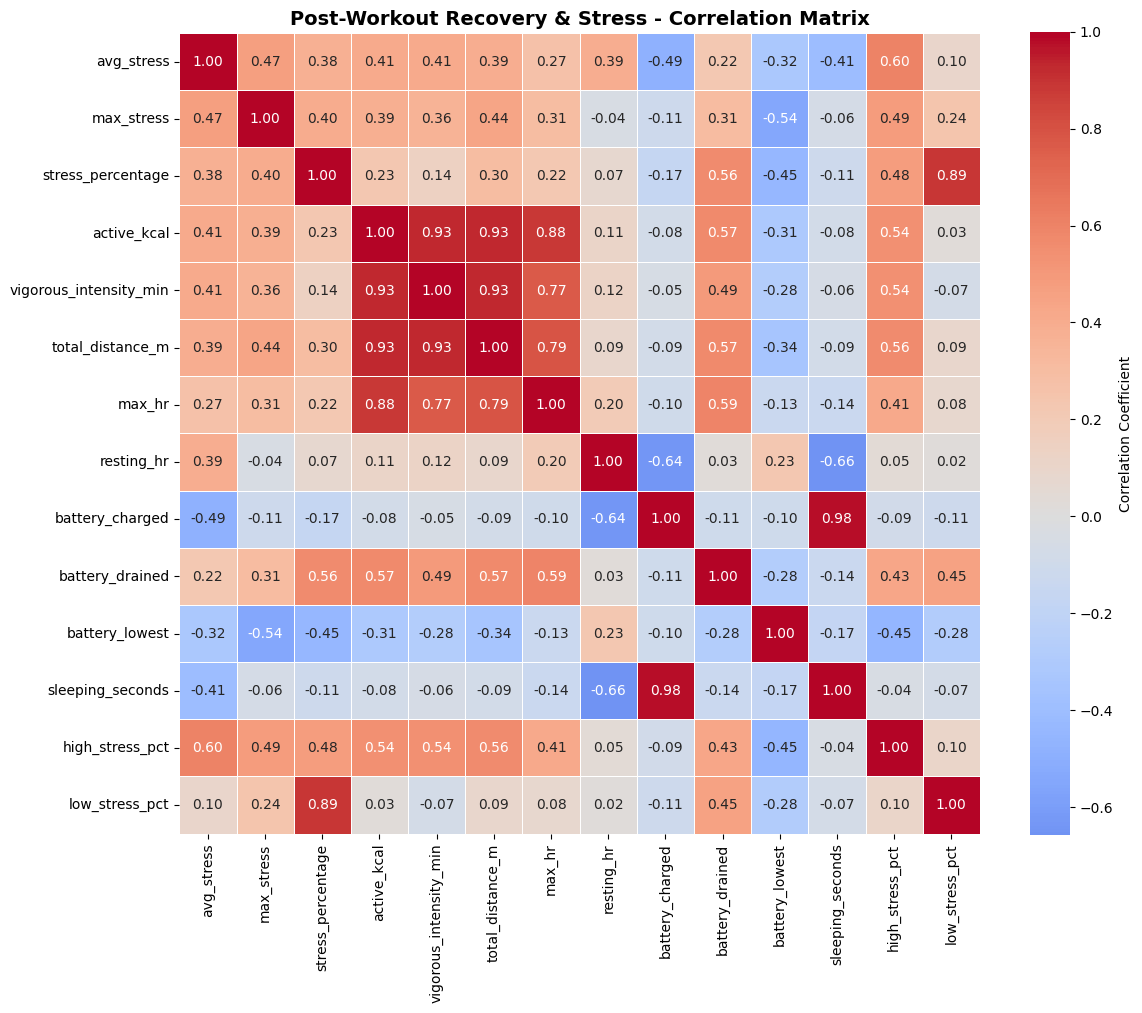


Analyzed 14 key recovery features


In [7]:
# Select only relevant features for cleaner visualization (exclude redundant ones)
selected_features = [
    'avg_stress', 'max_stress', 'stress_percentage',
    'active_kcal', 'vigorous_intensity_min', 'total_distance_m',
    'max_hr', 'resting_hr',
    'battery_charged', 'battery_drained', 'battery_lowest',
    'sleeping_seconds', 'high_stress_pct', 'low_stress_pct'
]

# Filter to only features that exist in the data
selected_features = [f for f in selected_features if f in df_valid.columns]

# Create correlation matrix for selected features
corr_selected = df_valid[selected_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation Coefficient'},
            square=True, linewidths=0.5)
plt.title('Post-Workout Recovery & Stress - Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nAnalyzed {len(selected_features)} key recovery features")

## 7. Key Findings - Top Correlations with Stress

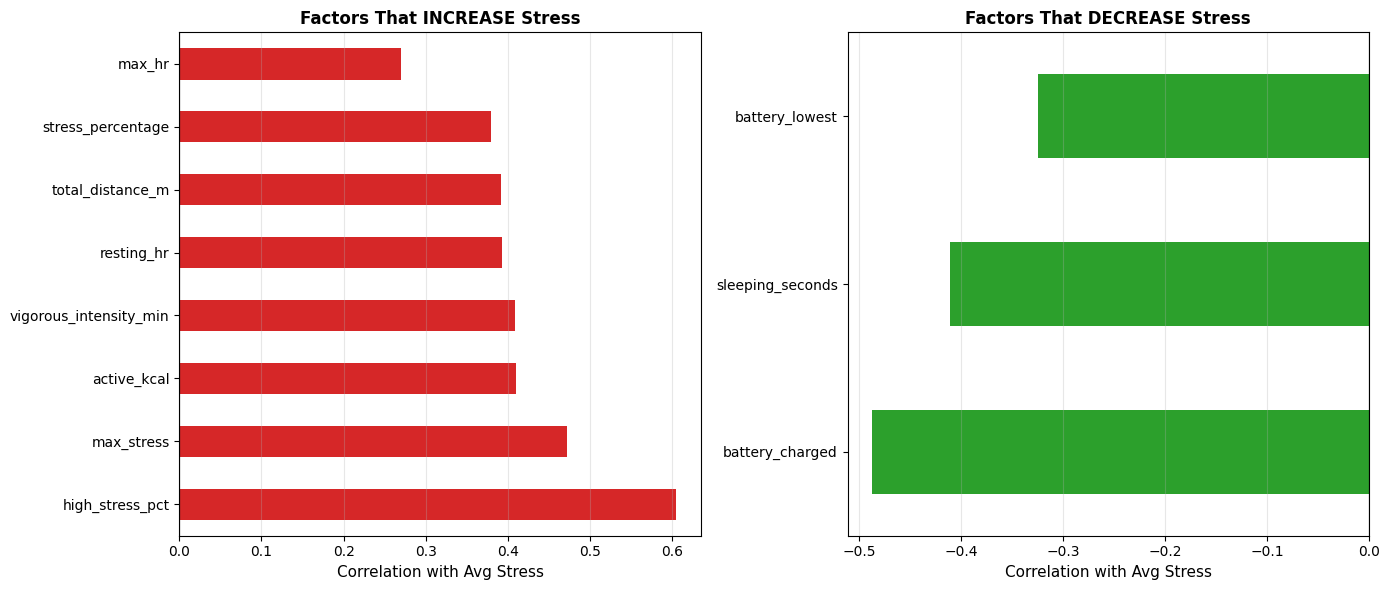

In [8]:
# Get top correlations with stress
stress_correlations = corr_selected['avg_stress'].drop('avg_stress').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive correlations (increase stress)
ax1 = axes[0]
top_positive = stress_correlations[stress_correlations > 0].nlargest(8)
top_positive.plot(kind='barh', ax=ax1, color='#d62728')
ax1.set_xlabel('Correlation with Avg Stress', fontsize=11)
ax1.set_title('Factors That INCREASE Stress', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

# Negative correlations (decrease stress)
ax2 = axes[1]
top_negative = stress_correlations[stress_correlations < 0].nsmallest(8)
top_negative.plot(kind='barh', ax=ax2, color='#2ca02c')
ax2.set_xlabel('Correlation with Avg Stress', fontsize=11)
ax2.set_title('Factors That DECREASE Stress', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Detailed Analysis: Workout Impact on Recovery Stress

In [9]:
# Compare stress metrics on workout vs rest days
comparison = df_valid.groupby('workout_intensity')[['avg_stress', 'max_stress', 'resting_hr', 
                                                       'battery_charged', 'battery_drained', 
                                                       'sleeping_seconds']].agg(['count', 'mean', 'std'])

print("\nStress & Recovery by Workout Intensity:")
print("="*80)
print(comparison.round(2))

# Statistical significance
workout_days = df_valid[df_valid['is_workout_day'] == True]['avg_stress']
rest_days = df_valid[df_valid['is_workout_day'] == False]['avg_stress']

print(f"\nWorkout Days - Avg Stress: {workout_days.mean():.2f} ± {workout_days.std():.2f}")
print(f"Rest Days - Avg Stress: {rest_days.mean():.2f} ± {rest_days.std():.2f}")
print(f"Difference: {abs(workout_days.mean() - rest_days.mean()):.2f} (Workout days have higher stress)")


Stress & Recovery by Workout Intensity:
                  avg_stress               max_stress                \
                       count   mean    std      count   mean    std   
workout_intensity                                                     
Rest                      29  29.66  13.73         29  85.38   6.47   
Light                     24  31.54   9.97         24  82.42  10.57   
Moderate                  33  36.21  14.33         33  88.97   7.77   
Hard                       7  50.29  10.87          7  95.43   3.10   

                  resting_hr              battery_charged                \
                       count   mean   std           count   mean    std   
workout_intensity                                                         
Rest                      29  59.14  6.73              29  10.76  21.90   
Light                     24  59.12  5.17              24   9.62  20.48   
Moderate                  33  59.73  5.96              33  12.48  19.79   
Hard       

## 9. Scatter Plots - Key Relationships

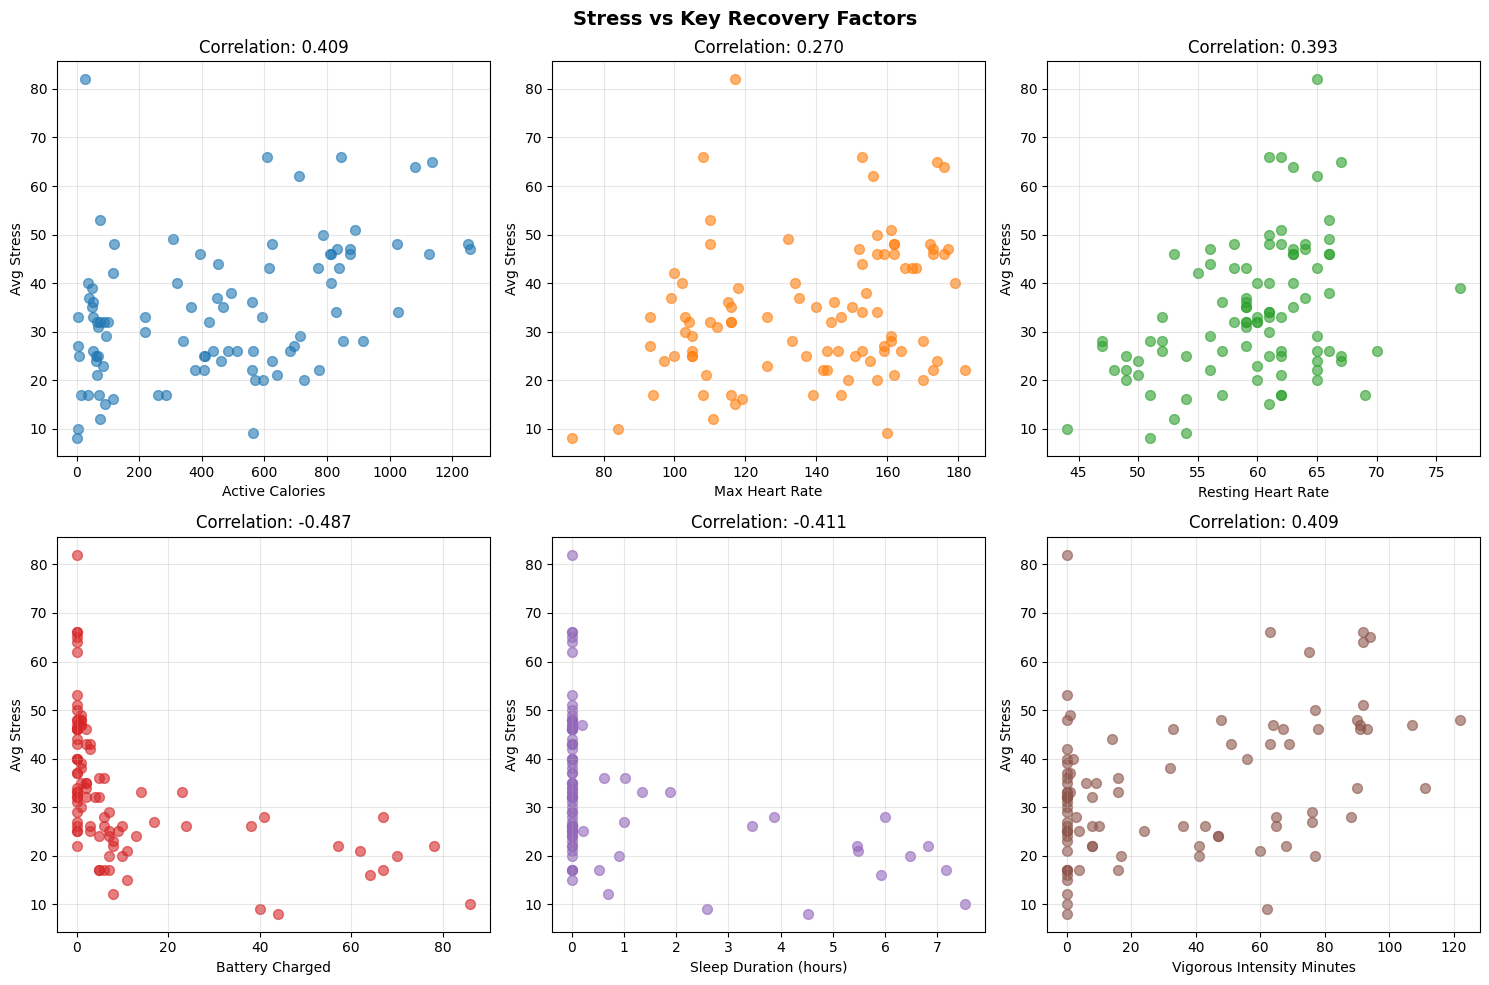

In [10]:
# Plot key relationships with stress
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Stress vs Key Recovery Factors', fontsize=14, fontweight='bold')

# 1. Active Calories vs Stress
axes[0, 0].scatter(df_valid['active_kcal'], df_valid['avg_stress'], alpha=0.6, s=50, color='#1f77b4')
axes[0, 0].set_xlabel('Active Calories')
axes[0, 0].set_ylabel('Avg Stress')
axes[0, 0].set_title(f'Correlation: {corr_selected.loc["avg_stress", "active_kcal"]:.3f}')
axes[0, 0].grid(alpha=0.3)

# 2. Max HR vs Stress
axes[0, 1].scatter(df_valid['max_hr'], df_valid['avg_stress'], alpha=0.6, s=50, color='#ff7f0e')
axes[0, 1].set_xlabel('Max Heart Rate')
axes[0, 1].set_ylabel('Avg Stress')
axes[0, 1].set_title(f'Correlation: {corr_selected.loc["avg_stress", "max_hr"]:.3f}')
axes[0, 1].grid(alpha=0.3)

# 3. Resting HR vs Stress
axes[0, 2].scatter(df_valid['resting_hr'], df_valid['avg_stress'], alpha=0.6, s=50, color='#2ca02c')
axes[0, 2].set_xlabel('Resting Heart Rate')
axes[0, 2].set_ylabel('Avg Stress')
axes[0, 2].set_title(f'Correlation: {corr_selected.loc["avg_stress", "resting_hr"]:.3f}')
axes[0, 2].grid(alpha=0.3)

# 4. Battery Charged vs Stress
axes[1, 0].scatter(df_valid['battery_charged'], df_valid['avg_stress'], alpha=0.6, s=50, color='#d62728')
axes[1, 0].set_xlabel('Battery Charged')
axes[1, 0].set_ylabel('Avg Stress')
axes[1, 0].set_title(f'Correlation: {corr_selected.loc["avg_stress", "battery_charged"]:.3f}')
axes[1, 0].grid(alpha=0.3)

# 5. Sleep Duration vs Stress
df_valid['sleep_hours'] = df_valid['sleeping_seconds'] / 3600
axes[1, 1].scatter(df_valid['sleep_hours'], df_valid['avg_stress'], alpha=0.6, s=50, color='#9467bd')
axes[1, 1].set_xlabel('Sleep Duration (hours)')
axes[1, 1].set_ylabel('Avg Stress')
axes[1, 1].set_title(f'Correlation: {corr_selected.loc["avg_stress", "sleeping_seconds"]:.3f}')
axes[1, 1].grid(alpha=0.3)

# 6. Vigorous Intensity Minutes vs Stress
axes[1, 2].scatter(df_valid['vigorous_intensity_min'], df_valid['avg_stress'], alpha=0.6, s=50, color='#8c564b')
axes[1, 2].set_xlabel('Vigorous Intensity Minutes')
axes[1, 2].set_ylabel('Avg Stress')
axes[1, 2].set_title(f'Correlation: {corr_selected.loc["avg_stress", "vigorous_intensity_min"]:.3f}')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary & Key Insights

In [11]:
print("\n" + "="*80)
print("POST-WORKOUT RECOVERY & STRESS ANALYSIS - KEY FINDINGS")
print("="*80)

# Top positive correlations (factors increasing stress)
print("\n✗ FACTORS THAT INCREASE STRESS (Negative for Recovery):")
print("-" * 60)
top_pos = stress_correlations[stress_correlations > 0].nlargest(5)
for i, (feat, corr) in enumerate(top_pos.items(), 1):
    print(f"{i}. {feat}: {corr:+.3f}")

# Top negative correlations (factors decreasing stress)
print("\n✓ FACTORS THAT DECREASE STRESS (Positive for Recovery):")
print("-" * 60)
top_neg = stress_correlations[stress_correlations < 0].nsmallest(5)
for i, (feat, corr) in enumerate(top_neg.items(), 1):
    print(f"{i}. {feat}: {corr:+.3f}")

print("\n" + "="*80)
print(f"Analysis based on {len(df_valid)} days ({df_valid['is_workout_day'].sum()} workout days)")
print(f"Date range: {df_valid['date'].min().date()} to {df_valid['date'].max().date()}")
print("="*80)


POST-WORKOUT RECOVERY & STRESS ANALYSIS - KEY FINDINGS

✗ FACTORS THAT INCREASE STRESS (Negative for Recovery):
------------------------------------------------------------
1. high_stress_pct: +0.605
2. max_stress: +0.471
3. active_kcal: +0.409
4. vigorous_intensity_min: +0.409
5. resting_hr: +0.393

✓ FACTORS THAT DECREASE STRESS (Positive for Recovery):
------------------------------------------------------------
1. battery_charged: -0.487
2. sleeping_seconds: -0.411
3. battery_lowest: -0.325

Analysis based on 94 days (64 workout days)
Date range: 2026-04-16 to 2026-07-18
